# BSDE-CFFT Stochastic Volatility Demo

This notebook mirrors the main experiment script: 1D Black-Scholes validation, 2D Heston benchmarking, 2D GARCH diffusion benchmarking, and grid/damping sensitivity diagnostics. It also adds a few plots to make convergence, runtime, and sensitivity trends easier to read.

In [1]:
# Cell 1 — local install or Colab install
import subprocess
import sys
from pathlib import Path

candidates = [Path.cwd(), Path.cwd().parent]
repo_root = next((p.resolve() for p in candidates if (p / "pyproject.toml").exists()), None)

if repo_root is not None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(repo_root), "--quiet"])
    print(f"Installed local package from {repo_root}")
else:
    print("Local repository not found from this notebook.")
    print("On Colab after pushing to GitHub, use:")
    print("%pip install \"git+https://github.com/YOUR_USER/YOUR_REPO.git\" --quiet")


Installed local package from /Users/raph/Documents/Columbia/Numerical Methods/Projet2



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [2]:
# Cell 2 — imports
import sys
import time
from pathlib import Path

candidates = [Path.cwd(), Path.cwd().parent]
repo_root = next((p.resolve() for p in candidates if (p / "pyproject.toml").exists()), None)
if repo_root is not None and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bsde_cfft_sv import BSDECFFT1D, GARCHDiffusionBSDECFFT, HestonBSDECFFT, bs_call_delta, bs_call_price
from bsde_cfft_sv._benchmarks import (
    garch_diffusion_approx_price,
    garch_diffusion_mc_milstein,
    garch_diffusion_pyfeng_delta_fd,
    garch_diffusion_pyfeng_mc_price,
    garch_diffusion_pyfeng_price,
    garch_diffusion_pyfeng_z_fd,
    heston_call_price,
    heston_delta_fd,
    heston_mc_milstein,
    heston_pyfeng_price,
    heston_z_fd,
)


## Part I — 1D Black-Scholes validation

In [3]:
S0, K, r, sigma, T = 100.0, 100.0, 0.01, 0.2, 1.0
L, alpha, n_steps = 10.0, -3.0, 1000
price_bs = bs_call_price(S0, K, r, sigma, T)
delta_bs = bs_call_delta(S0, K, r, sigma, T)

bs_rows = []
for N in [1024, 2048, 4096, 8192]:
    t0 = time.time()
    solver = BSDECFFT1D(r=r, mu=r, sigma=sigma, K=K, T=T, L=L, N=N, n_steps=n_steps, alpha=alpha)
    price_num, delta_num = solver.price_at(S0)
    elapsed = time.time() - t0
    bs_rows.append({
        "N": N,
        "price": price_num,
        "abs_price_error": abs(price_num - price_bs),
        "delta": delta_num,
        "abs_delta_error": abs(delta_num - delta_bs),
        "time_s": elapsed,
    })

bs_df = pd.DataFrame(bs_rows)
print(f"Black-Scholes analytic price = {price_bs:.6f}, delta = {delta_bs:.6f}")
bs_df

Black-Scholes analytic price = 8.433319, delta = 0.559618


,N,price,abs_price_error,delta,abs_delta_error,time_s
0,1024,8.431795,0.001524,0.559619,0.000001,0.099350
1,2048,8.432926,0.000392,0.559623,0.000005,0.135149
2,4096,8.433220,0.000098,0.559623,0.000006,0.200050
3,8192,8.433294,0.000025,0.559623,0.000006,0.421087


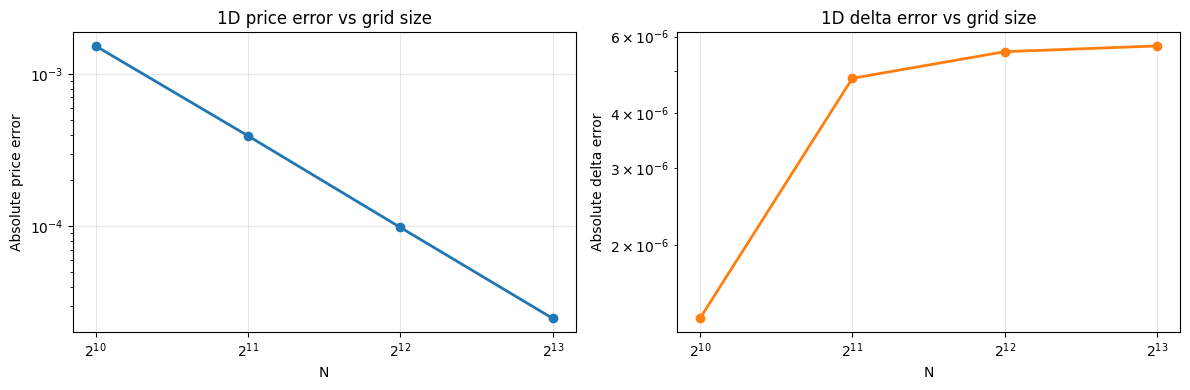

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(bs_df["N"], bs_df["abs_price_error"], marker="o", linewidth=2)
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_title("1D price error vs grid size")
axes[0].set_xlabel("N")
axes[0].set_ylabel("Absolute price error")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bs_df["N"], bs_df["abs_delta_error"], marker="o", linewidth=2, color="tab:orange")
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_title("1D delta error vs grid size")
axes[1].set_xlabel("N")
axes[1].set_ylabel("Absolute delta error")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part II — 2D Heston benchmark

In [5]:
S0, K = 100.0, 100.0
r = 0.05
kappa, theta, xi, rho, V0, T = 2.0, 0.04, 0.3, -0.7, 0.04, 1.0

heston_ref_price = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_delta = heston_delta_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_ref_zx, heston_ref_zv = heston_z_fd(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_pf_price = heston_pyfeng_price(S0, K, r, kappa, theta, xi, rho, V0, T)
heston_mc_price, heston_mc_se = heston_mc_milstein(S0, K, r, kappa, theta, xi, rho, V0, T, n_paths=100000, n_steps=500)

heston_configs = [
    (32, 16, 0.25, 200),
    (64, 32, 0.25, 500),
    (96, 48, 0.25, 700),
    (128, 64, 0.25, 900),
    (160, 80, 0.25, 1100),
]

heston_rows = []
for Nx, Nv, Lv, n_steps in heston_configs:
    t0 = time.time()
    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    heston_rows.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "Lv": Lv,
        "n_steps": n_steps,
        "price": price_num,
        "abs_price_error": abs(price_num - heston_ref_price),
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - heston_ref_zx),
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - heston_ref_zv),
        "time_s": elapsed,
    })

heston_df = pd.DataFrame(heston_rows)
print(f"Heston analytic price = {heston_ref_price:.6f}")
print(f"Heston analytic delta ≈ {heston_ref_delta:.6f}")
print(f"Heston FD controls: Zx ≈ {heston_ref_zx:.6f}, Zv ≈ {heston_ref_zv:.6f}")
print(f"PyFeng Heston FFT price = {heston_pf_price:.6f}")
print(f"Monte Carlo Milstein = {heston_mc_price:.6f} ± {2*heston_mc_se:.6f}")
heston_df

Heston analytic price = 10.394219
Heston analytic delta ≈ 0.691867
Heston FD controls: Zx ≈ 12.190396, Zv ≈ 1.680223
PyFeng Heston FFT price = 10.394219
Monte Carlo Milstein = 10.437888 ± 0.077569


,Nx,Nv,grid_points,Lv,n_steps,price,abs_price_error,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,0.25,200,8.608468,1.785751,0.692313,12.216397,0.026001,1.594133,0.086090,0.077615
1,64,32,2048,0.25,500,10.243828,0.150391,0.681494,12.147834,0.042562,1.505821,0.174402,0.223410
2,96,48,4608,0.25,700,10.353906,0.040313,0.685386,12.161497,0.028899,1.570231,0.109992,1.106789
3,128,64,8192,0.25,900,10.377017,0.017202,0.687584,12.167847,0.022549,1.612908,0.067315,2.678611
4,160,80,12800,0.25,1100,10.384226,0.009992,0.688907,12.175802,0.014594,1.632607,0.047616,2.833311


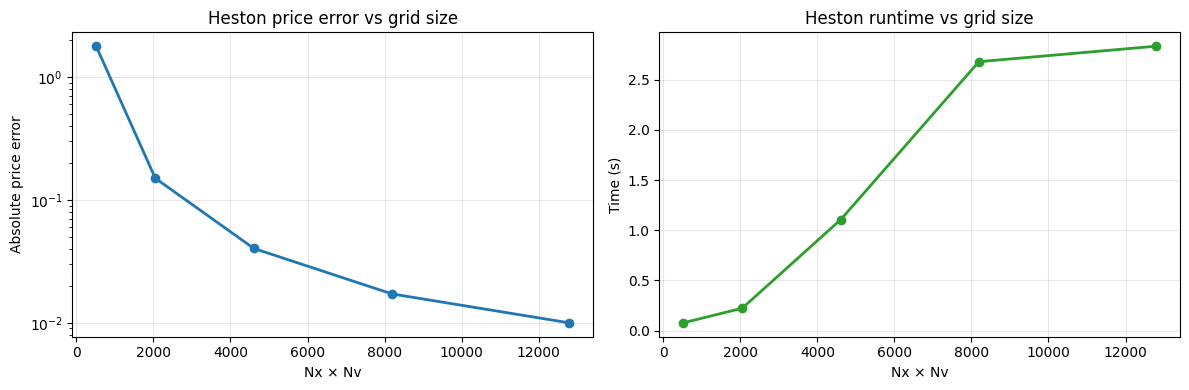

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(heston_df["grid_points"], heston_df["abs_price_error"], marker="o", linewidth=2)
axes[0].set_title("Heston price error vs grid size")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute price error")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(heston_df["grid_points"], heston_df["time_s"], marker="o", linewidth=2, color="tab:green")
axes[1].set_title("Heston runtime vs grid size")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

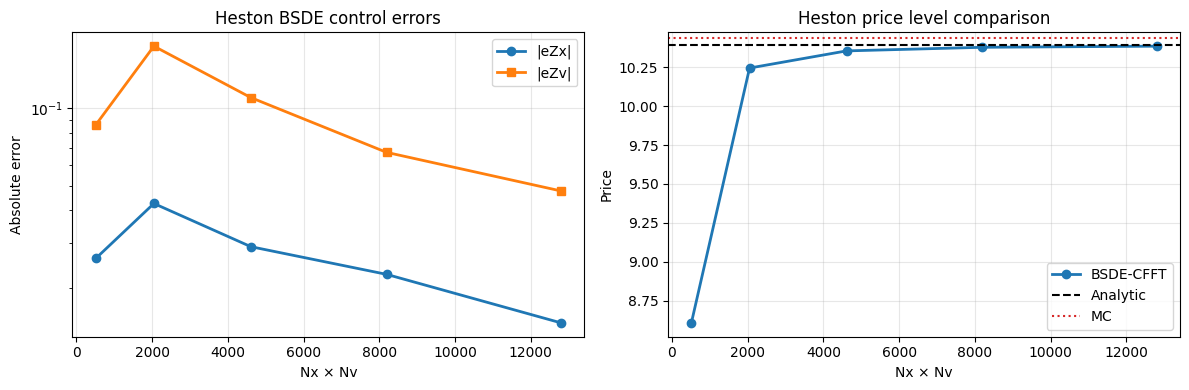

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(heston_df["grid_points"], heston_df["abs_zx_error"], marker="o", linewidth=2, label="|eZx|")
axes[0].plot(heston_df["grid_points"], heston_df["abs_zv_error"], marker="s", linewidth=2, label="|eZv|")
axes[0].set_title("Heston BSDE control errors")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute error")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(heston_df["grid_points"], heston_df["price"], marker="o", linewidth=2, label="BSDE-CFFT")
axes[1].axhline(heston_ref_price, color="black", linestyle="--", label="Analytic")
axes[1].axhline(heston_mc_price, color="tab:red", linestyle=":", label="MC")
axes[1].set_title("Heston price level comparison")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Price")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part III — 2D GARCH diffusion benchmark

In [8]:
S0, K = 100.0, 100.0
r, mu, a, b, c, V0, T = 0.05, 0.05, 2.0, 0.04, 0.4, 0.04, 1.0

garch_configs = [
    (32, 16, 0.32, 200),
    (64, 32, 0.32, 500),
    (96, 48, 0.32, 700),
    (128, 64, 0.32, 900),
    (160, 80, 0.32, 1100),
]

rho0 = 0.0
garch_price_approx, sigma_eff = garch_diffusion_approx_price(S0, K, r, mu, a, b, c, V0, T)
garch_pf_price = garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
garch_pf_delta = garch_diffusion_pyfeng_delta_fd(S0, K, r, a, b, c, V0, T)
garch_pf_z = garch_diffusion_pyfeng_z_fd(S0, K, r, a, b, c, rho0, V0, T)
garch_mc_price_rho0, garch_mc_se_rho0 = garch_diffusion_mc_milstein(S0, K, r, mu, a, b, c, rho0, V0, T, n_paths=100000, n_steps=500)
garch_pf_mc_rho0 = garch_diffusion_pyfeng_mc_price(S0, K, r, a, b, c, rho0, V0, T, n_paths=100000, n_steps=500)

garch_rows_rho0 = []
for Nx, Nv, Lv, n_steps in garch_configs:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    garch_rows_rho0.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "Lv": Lv,
        "n_steps": n_steps,
        "price": price_num,
        "abs_price_error_vs_pyfeng": abs(price_num - garch_pf_price) if garch_pf_price is not None else np.nan,
        "delta": delta_num,
        "z_x": z_x_num,
        "abs_zx_error": abs(z_x_num - garch_pf_z[0]) if garch_pf_z is not None else np.nan,
        "z_v": z_v_num,
        "abs_zv_error": abs(z_v_num - garch_pf_z[1]) if garch_pf_z is not None else np.nan,
        "time_s": elapsed,
    })

garch_df_rho0 = pd.DataFrame(garch_rows_rho0)
print(f"Mean-var BS approx = {garch_price_approx:.6f} with sigma_eff = {sigma_eff:.4f}")
print(f"PyFeng BA order 2 price = {garch_pf_price:.6f}")
print(f"PyFeng delta ≈ {garch_pf_delta:.6f}")
print(f"PyFeng Z references: Zx ≈ {garch_pf_z[0]:.6f}, Zv ≈ {garch_pf_z[1]:.6f}")
print(f"Monte Carlo Milstein = {garch_mc_price_rho0:.6f} ± {2*garch_mc_se_rho0:.6f}")
print(f"PyFeng MC Milstein = {garch_pf_mc_rho0:.6f}")
garch_df_rho0

Mean-var BS approx = 10.450584 with sigma_eff = 0.2000
PyFeng BA order 2 price = 10.437383
PyFeng delta ≈ 0.637278
PyFeng Z references: Zx ≈ 12.745559, Zv ≈ 0.645984
Monte Carlo Milstein = 10.483523 ± 0.093495
PyFeng MC Milstein = 10.436958


,Nx,Nv,grid_points,Lv,n_steps,price,abs_price_error_vs_pyfeng,delta,z_x,abs_zx_error,z_v,abs_zv_error,time_s
0,32,16,512,0.32,200,8.902374,1.535009,0.666983,13.339373,0.593814,-0.191149,0.837133,0.059045
1,64,32,2048,0.32,500,10.931110,0.493728,0.642254,12.844966,0.099407,-0.977295,1.623279,0.229287
2,96,48,4608,0.32,700,10.590470,0.153088,0.638774,12.775394,0.029834,0.383826,0.262158,1.158666
3,128,64,8192,0.32,900,10.425887,0.011496,0.638432,12.768576,0.023017,0.617802,0.028182,2.298247
4,160,80,12800,0.32,1100,10.434585,0.002798,0.637992,12.759792,0.014232,0.589472,0.056512,2.496764


In [9]:
rho_corr = -0.5
garch_mc_price_corr, garch_mc_se_corr = garch_diffusion_mc_milstein(S0, K, r, mu, a, b, c, rho_corr, V0, T, n_paths=100000, n_steps=500)
garch_pf_mc_corr = garch_diffusion_pyfeng_mc_price(S0, K, r, a, b, c, rho_corr, V0, T, n_paths=100000, n_steps=500)

garch_rows_corr = []
for Nx, Nv, Lv, n_steps in garch_configs:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho_corr,
        K=K, T=T, Nx=Nx, Nv=Nv, Lx=10.0, Lv=Lv,
        n_steps=n_steps, v_center=V0, alpha_x=-3.0,
    )
    price_num, delta_num, z_x_num, z_v_num = solver.price_delta_z_at(S0, V0)
    elapsed = time.time() - t0
    garch_rows_corr.append({
        "Nx": Nx,
        "Nv": Nv,
        "grid_points": Nx * Nv,
        "price": price_num,
        "abs_price_error_vs_mc": abs(price_num - garch_mc_price_corr),
        "z_x": z_x_num,
        "z_v": z_v_num,
        "time_s": elapsed,
    })

garch_df_corr = pd.DataFrame(garch_rows_corr)
print(f"Correlated-case Monte Carlo = {garch_mc_price_corr:.6f} ± {2*garch_mc_se_corr:.6f}")
print(f"Correlated-case PyFeng MC = {garch_pf_mc_corr:.6f}")
garch_df_corr

Correlated-case Monte Carlo = 10.506790 ± 0.090167
Correlated-case PyFeng MC = 10.465541


,Nx,Nv,grid_points,price,abs_price_error_vs_mc,z_x,z_v,time_s
0,32,16,512,8.898683,1.608107,13.392884,-0.193488,0.070260
1,64,32,2048,10.947886,0.441096,13.199412,-0.986741,0.225775
2,96,48,4608,10.666436,0.159646,12.755577,0.260990,1.143515
3,128,64,8192,10.455351,0.051439,12.644348,0.536376,2.264980
4,160,80,12800,10.456805,0.049985,12.645065,0.506802,2.590942


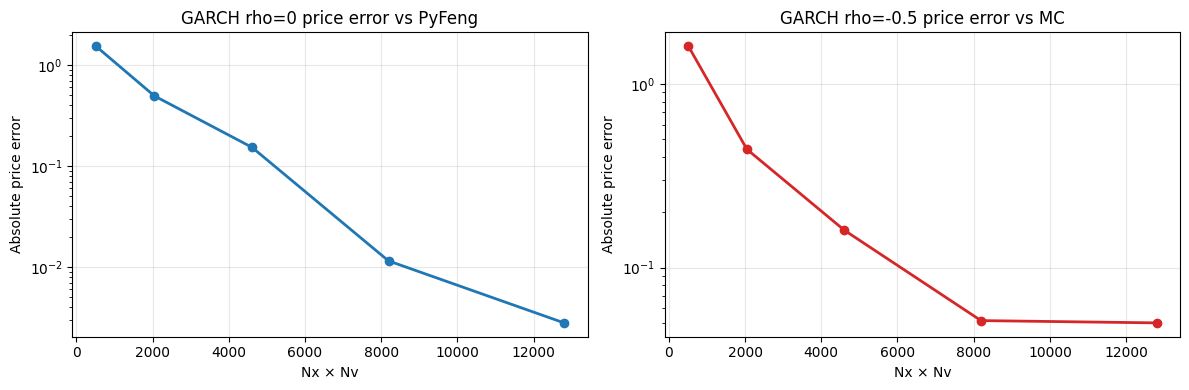

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(garch_df_rho0["grid_points"], garch_df_rho0["abs_price_error_vs_pyfeng"], marker="o", linewidth=2)
axes[0].set_title("GARCH rho=0 price error vs PyFeng")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute price error")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(garch_df_corr["grid_points"], garch_df_corr["abs_price_error_vs_mc"], marker="o", linewidth=2, color="tab:red")
axes[1].set_title("GARCH rho=-0.5 price error vs MC")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Absolute price error")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

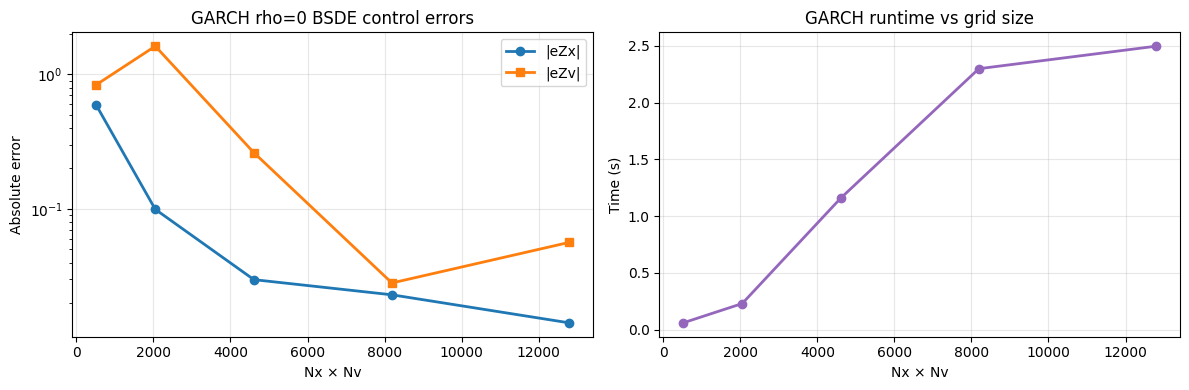

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(garch_df_rho0["grid_points"], garch_df_rho0["abs_zx_error"], marker="o", linewidth=2, label="|eZx|")
axes[0].plot(garch_df_rho0["grid_points"], garch_df_rho0["abs_zv_error"], marker="s", linewidth=2, label="|eZv|")
axes[0].set_title("GARCH rho=0 BSDE control errors")
axes[0].set_xlabel("Nx × Nv")
axes[0].set_ylabel("Absolute error")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(garch_df_rho0["grid_points"], garch_df_rho0["time_s"], marker="o", linewidth=2, color="tab:purple")
axes[1].set_title("GARCH runtime vs grid size")
axes[1].set_xlabel("Nx × Nv")
axes[1].set_ylabel("Time (s)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part IV — Sensitivity diagnostics

In [12]:
S0, K, r, V0, T = 100.0, 100.0, 0.05, 0.04, 1.0

kappa, theta, xi, rho = 2.0, 0.04, 0.3, -0.7
ref_heston = heston_call_price(S0, K, r, kappa, theta, xi, rho, V0, T)
lv_rows = []
for Lv in [0.15, 0.20, 0.25, 0.30, 0.40]:
    t0 = time.time()
    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=Lv,
        n_steps=700, v_center=V0, alpha_x=-3.0,
    )
    price, _ = solver.price_at(S0, V0)
    lv_rows.append({"Lv": Lv, "price": price, "abs_price_error": abs(price - ref_heston), "time_s": time.time() - t0})
lv_df = pd.DataFrame(lv_rows)

boundary_rows = []
for v_boundary in ["none", "neumann"]:
    t0 = time.time()
    solver = HestonBSDECFFT(
        r=r, kappa=kappa, theta=theta, xi=xi, rho=rho,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.20,
        n_steps=700, v_center=V0, alpha_x=-3.0, v_boundary=v_boundary,
    )
    price, _ = solver.price_at(S0, V0)
    boundary_rows.append({"v_boundary": v_boundary, "price": price, "abs_price_error": abs(price - ref_heston), "time_s": time.time() - t0})
boundary_df = pd.DataFrame(boundary_rows)

mu, a, b, c, rho0 = 0.05, 2.0, 0.04, 0.4, 0.0
ref_garch = garch_diffusion_pyfeng_price(S0, K, r, a, b, c, V0, T)
alpha_rows = []
for alpha_x in [-2.5, -3.0, -3.5]:
    t0 = time.time()
    solver = GARCHDiffusionBSDECFFT(
        r=r, mu=mu, a=a, b=b, c=c, rho=rho0,
        K=K, T=T, Nx=96, Nv=48, Lx=10.0, Lv=0.32,
        n_steps=700, v_center=V0, alpha_x=alpha_x,
    )
    price, _ = solver.price_at(S0, V0)
    alpha_rows.append({"alpha_x": alpha_x, "price": price, "abs_price_error": abs(price - ref_garch), "time_s": time.time() - t0})
alpha_df = pd.DataFrame(alpha_rows)

display(lv_df)
display(boundary_df)
display(alpha_df)

,Lv,price,abs_price_error,time_s
0,0.15,10.253458,0.140760,1.159945
1,0.20,10.308233,0.085985,1.266960
2,0.25,10.353906,0.040313,1.286356
3,0.30,10.412480,0.018261,1.256387
4,0.40,10.537274,0.143055,1.234129


,v_boundary,price,abs_price_error,time_s
0,none,10.243520,0.150698,1.224931
1,neumann,10.308233,0.085985,1.198005


,alpha_x,price,abs_price_error,time_s
0,-2.5,10.591145,0.153763,1.147042
1,-3.0,10.590470,0.153088,1.145573
2,-3.5,10.589758,0.152375,1.216600


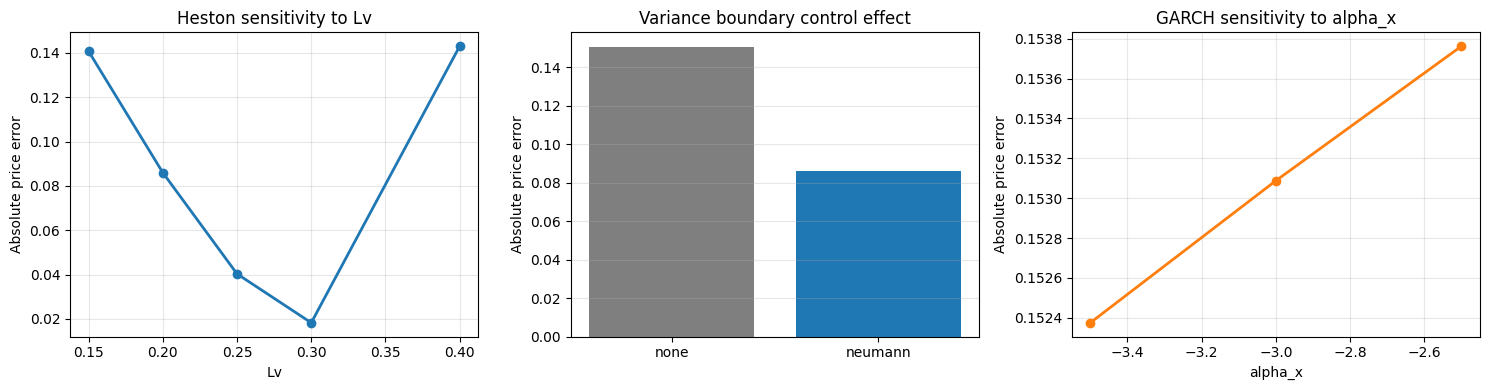

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(lv_df["Lv"], lv_df["abs_price_error"], marker="o", linewidth=2)
axes[0].set_title("Heston sensitivity to Lv")
axes[0].set_xlabel("Lv")
axes[0].set_ylabel("Absolute price error")
axes[0].grid(True, alpha=0.3)

axes[1].bar(boundary_df["v_boundary"], boundary_df["abs_price_error"], color=["tab:gray", "tab:blue"])
axes[1].set_title("Variance boundary control effect")
axes[1].set_ylabel("Absolute price error")
axes[1].grid(True, axis="y", alpha=0.3)

axes[2].plot(alpha_df["alpha_x"], alpha_df["abs_price_error"], marker="o", linewidth=2, color="tab:orange")
axes[2].set_title("GARCH sensitivity to alpha_x")
axes[2].set_xlabel("alpha_x")
axes[2].set_ylabel("Absolute price error")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()